In [2]:
# 📌 Objectif : Rasteriser les prédictions du modèle GCN basé sur superpixels et générer un .tif

import pandas as pd
import numpy as np
import rasterio
from rasterio.transform import from_origin
from rasterio import features
from shapely.geometry import Point
import torch

In [122]:


# === 1. Charger les superpixels avec prédictions ===
df = pd.read_csv("superpixels_with_labels.csv")

# Charger modèle et graphe
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Charger le graphe
from torch_geometric.data import Data

data = torch.load("graph_superpixels.pt", weights_only=False)
model = GCN(in_channels=data.num_node_features, hidden_channels=16, out_channels=2)
model.load_state_dict(torch.load("gcn_model_superpixels.pt"))
model.eval()

# Prédictions
with torch.no_grad():
    preds = model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()
df["prediction"] = preds

# === 2. Charger le raster de base et les superpixels déjà générés ===
with rasterio.open("Matam_NDWI_SRTM_2024.tif") as src:
    profile = src.profile
    width, height = src.width, src.height
    transform = src.transform

# Charger les segments déjà calculés
segments = np.load("segments.npy")  # doit avoir été sauvegardé lors de la génération initiale

# === 3. Générer l’image raster prédite à partir des superpixels ===
predicted_raster = np.zeros((height, width), dtype=np.uint8)
for seg_id, label in zip(df["segment_id"], df["prediction"]):
    predicted_raster[segments == seg_id] = label

# === 4. Sauvegarder en GeoTIFF ===
profile.update({"count": 1, "dtype": "uint8"})
with rasterio.open("Prediction_GCN_Superpixels.tif", "w", **profile) as dst:
    dst.write(predicted_raster, 1)

print("✅ Carte prédite sauvegardée sous 'Prediction_GCN_Superpixels.tif'")


✅ Carte prédite sauvegardée sous 'Prediction_GCN_Superpixels.tif'


Seuil -0.20 → IoU: 75.33%, Overlap: 77.77%, Commission: 4.00%, Omission: 22.23%
Seuil -0.15 → IoU: 72.06%, Overlap: 73.54%, Commission: 2.73%, Omission: 26.46%
Seuil -0.10 → IoU: 67.21%, Overlap: 68.05%, Commission: 1.80%, Omission: 31.95%
Seuil -0.05 → IoU: 61.21%, Overlap: 61.64%, Commission: 1.14%, Omission: 38.36%
Seuil -0.00 → IoU: 54.43%, Overlap: 54.63%, Commission: 0.68%, Omission: 45.37%
Seuil 0.05 → IoU: 46.63%, Overlap: 46.71%, Commission: 0.38%, Omission: 53.29%
Seuil 0.10 → IoU: 37.29%, Overlap: 37.32%, Commission: 0.20%, Omission: 62.68%
Seuil 0.15 → IoU: 26.87%, Overlap: 26.87%, Commission: 0.07%, Omission: 73.13%
Seuil 0.20 → IoU: 15.61%, Overlap: 15.61%, Commission: 0.01%, Omission: 84.39%
Seuil 0.25 → IoU: 5.20%, Overlap: 5.20%, Commission: 0.01%, Omission: 94.80%
Seuil 0.30 → IoU: 0.90%, Overlap: 0.90%, Commission: 0.01%, Omission: 99.10%


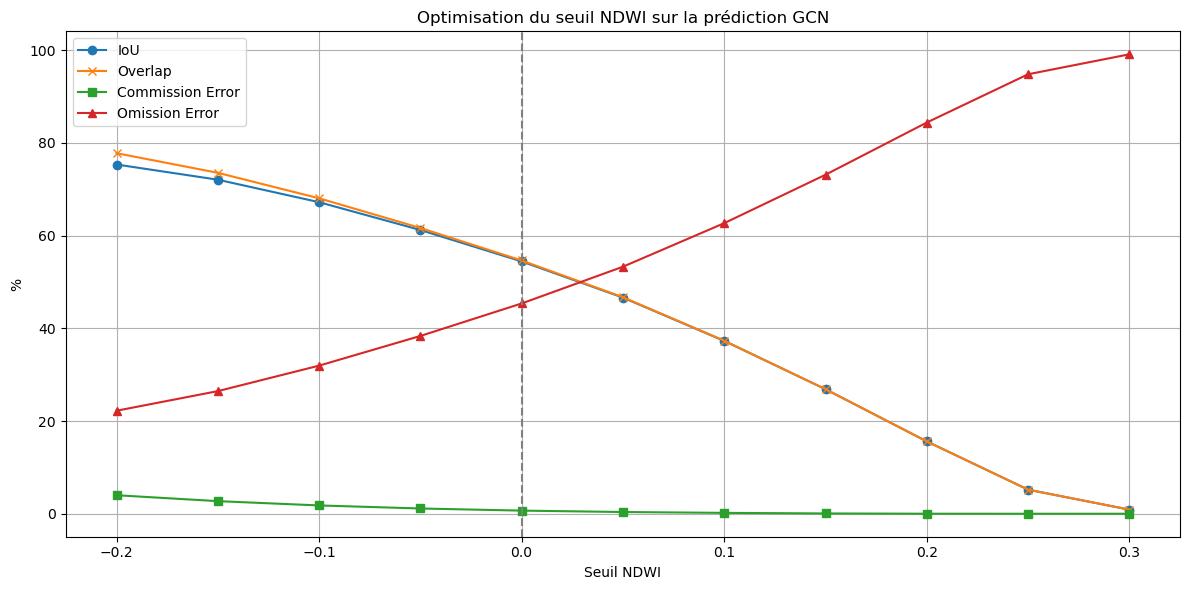

In [134]:
# 📌 Optimisation du seuil NDWI pour le post-traitement GCN

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as Rsp

# === 1. Charger la carte GCN et la carte de référence UNOSAT ===
pred_path = "Prediction_GCN_Superpixels.tif"
ndwi_path = "Matam_NDWI_SRTM_2024.tif"
ref_path = "WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif"

with rasterio.open(ref_path) as src_ref:
    ref = src_ref.read(1).astype(np.uint8)
    ref_profile = src_ref.profile
    ref_crs = src_ref.crs
    ref_transform = src_ref.transform
    ref_shape = src_ref.shape

with rasterio.open(pred_path) as src_pred:
    pred = src_pred.read(1)
    pred_crs = src_pred.crs
    pred_transform = src_pred.transform

with rasterio.open(ndwi_path) as src_ndwi:
    ndwi = src_ndwi.read(1)

# === 2. Reprojecter NDWI et Prédiction vers le raster de référence ===
ndwi_aligned = np.zeros(ref_shape, dtype=np.float32)
pred_aligned = np.zeros(ref_shape, dtype=np.uint8)

reproject(ndwi, ndwi_aligned,
          src_transform=src_ndwi.transform, src_crs=src_ndwi.crs,
          dst_transform=ref_transform, dst_crs=ref_crs,
          resampling=Resampling.bilinear)

reproject(pred, pred_aligned,
          src_transform=pred_transform, src_crs=pred_crs,
          dst_transform=ref_transform, dst_crs=ref_crs,
          resampling=Resampling.nearest)

# === 3. Boucle sur les seuils NDWI ===
thresholds = np.arange(-0.2, 0.31, 0.05)
iou_list, overlap_list, commission_list, omission_list = [], [], [], []

for thresh in thresholds:
    mask = ndwi_aligned > thresh
    filtered = np.where((pred_aligned == 1) & mask, 1, 0).astype(np.uint8)

    intersection = np.logical_and(filtered == 1, ref == 1).sum()
    union = np.logical_or(filtered == 1, ref == 1).sum()
    iou = 100 * intersection / union if union > 0 else 0

    overlap = 100 * intersection / ref.sum() if ref.sum() > 0 else 0
    commission = 100 * ((filtered == 1).sum() - intersection) / filtered.sum() if filtered.sum() > 0 else 0
    omission = 100 * ((ref == 1).sum() - intersection) / ref.sum() if ref.sum() > 0 else 0

    iou_list.append(iou)
    overlap_list.append(overlap)
    commission_list.append(commission)
    omission_list.append(omission)

    print(f"Seuil {thresh:.2f} → IoU: {iou:.2f}%, Overlap: {overlap:.2f}%, Commission: {commission:.2f}%, Omission: {omission:.2f}%")

# === 4. Tracer les résultats ===
plt.figure(figsize=(12, 6))
plt.plot(thresholds, iou_list, label="IoU", marker='o')
plt.plot(thresholds, overlap_list, label="Overlap", marker='x')
plt.plot(thresholds, commission_list, label="Commission Error", marker='s')
plt.plot(thresholds, omission_list, label="Omission Error", marker='^')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("Seuil NDWI")
plt.ylabel("%")
plt.title("Optimisation du seuil NDWI sur la prédiction GCN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# 📌 Reprojection et resampling de la carte GCN vers le raster UNOSAT

import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# === 1. Ouvrir la référence UNOSAT ===
ref_path = "WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif"
with rasterio.open(ref_path) as ref:
    ref_profile = ref.profile
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# === 2. Ouvrir la carte prédite GCN ===
#pred_path = "Prediction_GCN_Superpixels.tif"
pred_path ="Matam_NDWI_SRTM_2024.tif"
with rasterio.open(pred_path) as src:
    data = src.read(1)
    src_profile = src.profile
    src_crs = src.crs
    src_transform = src.transform

# === 3. Créer un tableau vide avec dimensions et type de la carte UNOSAT ===
resampled = np.zeros(ref_shape, dtype=np.uint8)

# === 4. Reprojection + resampling bilinéaire (ou nearest pour classes) ===
reproject(
    source=data,
    destination=resampled,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=ref_transform,
    dst_crs=ref_crs,
    resampling=Resampling.nearest
)

# === 5. Sauvegarder la carte GCN reprojectée ===
#out_path = "Prediction_GCN_Superpixels_aligned.tif"
out_path = "Matam_NDWI_SRTM_2024_aligned.tif"
ref_profile.update({"count": 1, "dtype": "uint8"})
with rasterio.open(out_path, "w", **ref_profile) as dst:
    dst.write(resampled, 1)

print(f"✅ Carte GCN reprojetée et alignée sauvegardée sous '{out_path}'")

✅ Carte GCN reprojetée et alignée sauvegardée sous 'Matam_NDWI_SRTM_2024_aligned.tif'


✅ Seuil NDWI optimal : -0.50 avec IoU = 63.69 %


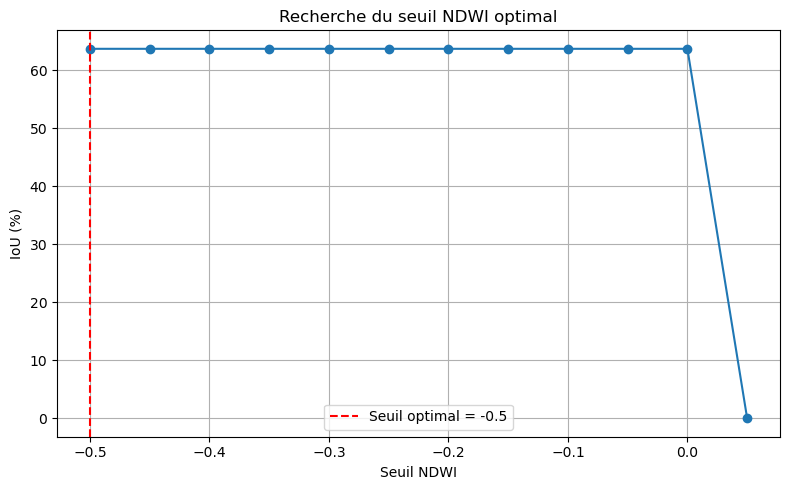

In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === Chemins
pred_path = 'Prediction_GCN_Superpixels_aligned.tif'
ndwi_path = 'Matam_NDWI_SRTM_2024_aligned.tif'
unosat_path = 'WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif'

# === Chargement des rasters
with rasterio.open(pred_path) as src:
    pred = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

with rasterio.open(unosat_path) as src:
    unosat = src.read(1)

# === Binarisation de UNOSAT
unosat_bin = (unosat == 1).astype(np.uint8)

# === Recherche du seuil optimal NDWI
best_iou = 0
best_thresh = None
iou_scores = []

for thresh in np.arange(-0.5, 0.1, 0.05):
    # Post-traitement
    post_pred = pred.copy()
    post_pred[(pred == 1) & (ndwi < thresh)] = 0
    post_bin = (post_pred == 1).astype(np.uint8)

    # Évaluation
    intersection = np.logical_and(post_bin, unosat_bin).sum()
    union = np.logical_or(post_bin, unosat_bin).sum()
    iou = intersection / union * 100 if union > 0 else 0

    iou_scores.append((thresh, iou))
    if iou > best_iou:
        best_iou = iou
        best_thresh = thresh

print(f"✅ Seuil NDWI optimal : {best_thresh:.2f} avec IoU = {best_iou:.2f} %")

# === Affichage
thresh_vals, iou_vals = zip(*iou_scores)
plt.figure(figsize=(8, 5))
plt.plot(thresh_vals, iou_vals, marker='o')
plt.title("Recherche du seuil NDWI optimal")
plt.xlabel("Seuil NDWI")
plt.ylabel("IoU (%)")
plt.grid()
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Seuil optimal = {best_thresh}')
plt.legend()
plt.tight_layout()
plt.show()

✅ Carte post-traitée sauvegardée sous 'Prediction_GCN_PostProcessed.tif'


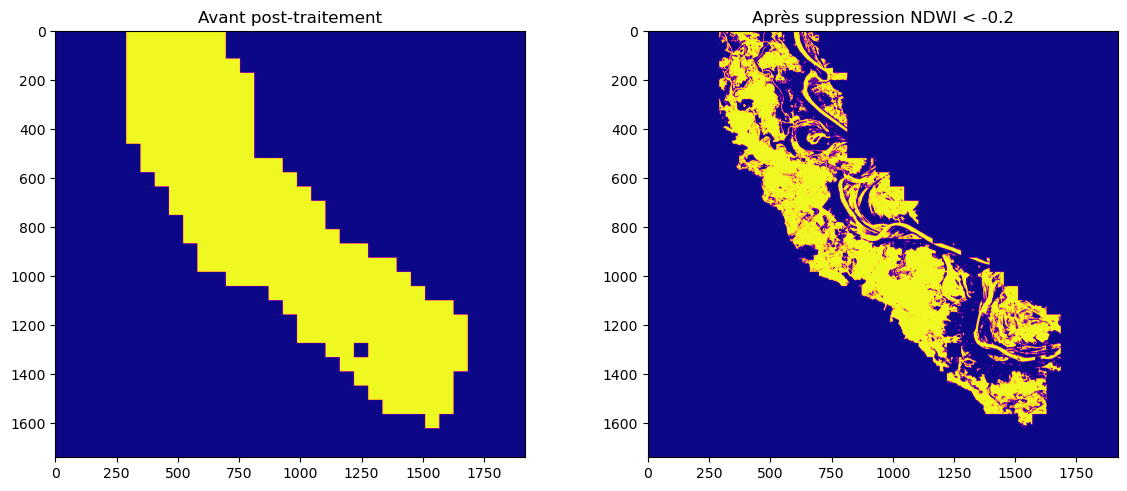

In [13]:
# 📌 Post-traitement : Réduire les faux positifs par seuillage NDWI (seuil optimal = -0.2)

import rasterio
import numpy as np
import matplotlib.pyplot as plt

# === 1. Charger la carte prédite et l'image NDWI ===
with rasterio.open("Prediction_GCN_Superpixels.tif") as src_pred:
    pred = src_pred.read(1)
    profile = src_pred.profile
    transform = src_pred.transform

with rasterio.open("Matam_NDWI_SRTM_2024.tif") as src_ref:
    ndwi = src_ref.read(1)  # Bande 1 = NDWI

# === 2. Appliquer le meilleur seuil NDWI > -0.2 ===
ndwi_mask = ndwi > -0.2
post_pred = np.where((pred == 1) & (~ndwi_mask), 0, pred)

# === 3. Sauvegarder la carte filtrée ===
profile.update({"count": 1, "dtype": "uint8"})
with rasterio.open("Prediction_GCN_PostProcessed.tif", "w", **profile) as dst:
    dst.write(post_pred.astype(np.uint8), 1)

print("✅ Carte post-traitée sauvegardée sous 'Prediction_GCN_PostProcessed.tif'")

# === 4. Visualiser la différence ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(pred, cmap="plasma")
plt.title("Avant post-traitement")

plt.subplot(1, 2, 2)
plt.imshow(post_pred, cmap="plasma")
plt.title("Après suppression NDWI < -0.2")
plt.tight_layout()
plt.show()


In [128]:
# 📌 Reprojection + calcul de surface inondée (en hectares) depuis un raster en EPSG:4326

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import os

# === 1. Reprojection vers EPSG:32628 (UTM zone 28N pour Matam) ===
input_path = "Prediction_GCN_PostProcessed.tif"
output_path = "Prediction_GCN_PostProcessed_UTM.tif"

dst_crs = "EPSG:32628"

with rasterio.open(input_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(output_path, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest)

print(f"✅ Raster reprojeté vers EPSG:32628 et sauvegardé sous '{output_path}'")

# === 2. Calcul de la surface inondée ===
with rasterio.open(output_path) as src:
    data = src.read(1)
    transform = src.transform
    res_x, res_y = transform[0], -transform[4]
    pixel_area_m2 = res_x * res_y
    flooded_pixels = (data == 1).sum()
    area_ha = (flooded_pixels * pixel_area_m2) / 10000

print(f"🌍 Résolution (m): {res_x:.2f} x {res_y:.2f}")
print(f"🌊 Pixels inondés: {flooded_pixels}")
print(f"✅ Surface inondée estimée : {area_ha:.2f} hectares")


✅ Raster reprojeté vers EPSG:32628 et sauvegardé sous 'Prediction_GCN_PostProcessed_UTM.tif'
🌍 Résolution (m): 29.32 x 29.32
🌊 Pixels inondés: 531789
✅ Surface inondée estimée : 45721.25 hectares


In [130]:
# 📌 Reprojection et resampling de la carte GCN vers le raster UNOSAT

import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

# === 1. Ouvrir la référence UNOSAT ===
ref_path = "WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif"
with rasterio.open(ref_path) as ref:
    ref_profile = ref.profile
    ref_shape = ref.shape
    ref_transform = ref.transform
    ref_crs = ref.crs

# === 2. Ouvrir la carte prédite GCN ===
pred_path = "Prediction_GCN_PostProcessed.tif"
with rasterio.open(pred_path) as src:
    data = src.read(1)
    src_profile = src.profile
    src_crs = src.crs
    src_transform = src.transform

# === 3. Créer un tableau vide avec dimensions et type de la carte UNOSAT ===
resampled = np.zeros(ref_shape, dtype=np.uint8)

# === 4. Reprojection + resampling bilinéaire (ou nearest pour classes) ===
reproject(
    source=data,
    destination=resampled,
    src_transform=src_transform,
    src_crs=src_crs,
    dst_transform=ref_transform,
    dst_crs=ref_crs,
    resampling=Resampling.nearest
)

# === 5. Sauvegarder la carte GCN reprojectée ===
out_path = "Prediction_GCN_PostProcessed_Aligned.tif"
ref_profile.update({"count": 1, "dtype": "uint8"})
with rasterio.open(out_path, "w", **ref_profile) as dst:
    dst.write(resampled, 1)

print(f"✅ Carte GCN reprojetée et alignée sauvegardée sous '{out_path}'")


✅ Carte GCN reprojetée et alignée sauvegardée sous 'Prediction_GCN_PostProcessed_Aligned.tif'


In [132]:
# 📌 Évaluation de la carte post-traitée vs carte de référence UNOSAT

import rasterio
import numpy as np

# === 1. Charger la carte prédite filtrée et la référence ===
with rasterio.open("Prediction_GCN_PostProcessed_Aligned.tif") as src_pred:
    pred = (src_pred.read(1) > 0).astype(np.uint8)  # binarisation stricte

print("Valeurs uniques dans la carte prédite :", np.unique(pred))


with rasterio.open("WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif") as src_ref:
    ref = src_ref.read(1).astype(np.uint8)

# === 2. S'assurer que les dimensions correspondent ===
assert pred.shape == ref.shape, "⚠️ Les dimensions des rasters ne correspondent pas."

# === 3. Calcul des métriques ===
intersection = np.logical_and(pred == 1, ref == 1).sum()
union = np.logical_or(pred == 1, ref == 1).sum()
iou = 100 * intersection / union if union > 0 else 0

overlap = 100 * intersection / ref.sum() if ref.sum() > 0 else 0
commission = 100 * ((pred == 1).sum() - intersection) / pred.sum() if pred.sum() > 0 else 0
omission = 100 * ((ref == 1).sum() - intersection) / ref.sum() if ref.sum() > 0 else 0

print("📊 Évaluation post-traitée vs UNOSAT")
print(f"Benchmark map: {ref.sum()}")
print(f"Prediction map: {pred.sum()}")
print(f"Intersection: {intersection}")
print(f"Union: {union}")
print(f"IoU: {iou:.2f}%")
print(f"Overlap Percentage: {overlap:.2f}%")
print(f"Commission Error: {commission:.2f}%")
print(f"Omission Error: {omission:.2f}%")


Valeurs uniques dans la carte prédite : [0 1]
📊 Évaluation post-traitée vs UNOSAT
Benchmark map: 4787251
Prediction map: 3850165
Intersection: 3697460
Union: 4939956
IoU: 74.85%
Overlap Percentage: 77.24%
Commission Error: 3.97%
Omission Error: 22.76%


C:\Users\YASSINE\AppData\Local\Temp\ipykernel_19992\967485846.py:48: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from current font.
  plt.tight_layout()
C:\Users\YASSINE\AppData\Local\Temp\ipykernel_19992\967485846.py:48: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from current font.
  plt.tight_layout()
C:\Users\YASSINE\AppData\Local\Temp\ipykernel_19992\967485846.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\YASSINE\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\YASSINE\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\YASSINE\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from c

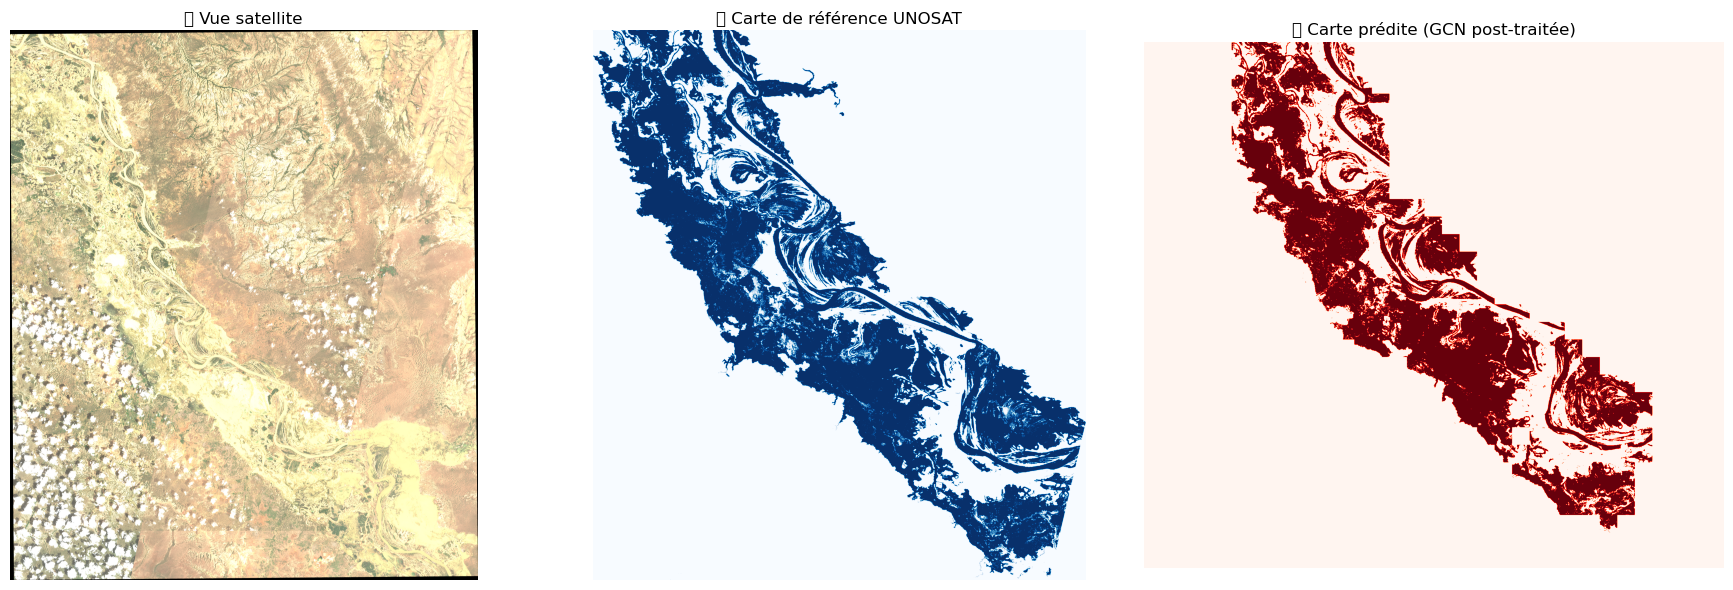

In [3]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

# === Chemins vers les fichiers ===
ref_path = "WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif"     # carte de référence UNOSAT
pred_path = "Prediction_GCN_PostProcessed.tif"                            # carte prédite (post-traitée)
sat_path = "Sentinel2_RGB_PostFlood_matam.tif"                                  # image satellite optionnelle (si disponible)

# === Chargement des rasters ===
with rasterio.open(ref_path) as src_ref:
    ref = src_ref.read(1)

with rasterio.open(pred_path) as src_pred:
    pred = src_pred.read(1)

# === Vérifier et charger image satellite si dispo ===
has_sat = os.path.exists(sat_path)
if has_sat:
    with rasterio.open(sat_path) as src_sat:
        rgb = src_sat.read([1, 2, 3])
        rgb = np.moveaxis(rgb, 0, -1)  # (bands, h, w) → (h, w, bands)
        rgb = np.clip(rgb / rgb.max(), 0, 1)  # Normalisation simple

# === Affichage ===
plt.figure(figsize=(18, 6))

# Image satellite
if has_sat:
    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("🛰️ Vue satellite")
    plt.axis("off")

# Référence UNOSAT
plt.subplot(1, 3 if has_sat else 2, 2 if has_sat else 1)
plt.imshow(ref, cmap="Blues")
plt.title("📘 Carte de référence UNOSAT")
plt.axis("off")

# Prédiction GCN
plt.subplot(1, 3 if has_sat else 2, 3 if has_sat else 2)
plt.imshow(pred, cmap="Reds")
plt.title("🔴 Carte prédite (GCN post-traitée)")
plt.axis("off")

plt.tight_layout()
plt.show()


✅ Image satellite reprojetée et alignée : Sentinel2_RGB_Aligned_matam.tif


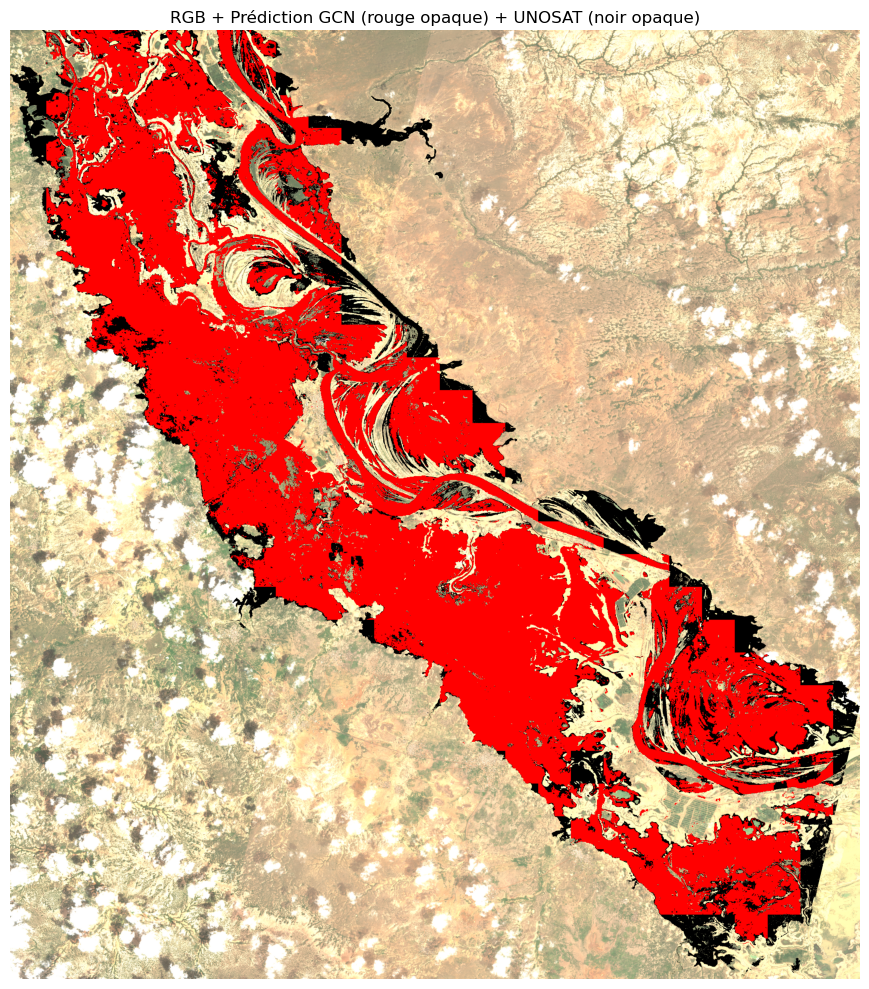

✅ Image exportée sans transparence : Fusion_RGB_GCN_UNOSAT_Opaque.png


In [23]:
# 📌 Reprojetter et recadrer une image satellite RGB sur la géométrie de la carte prédite (GCN) et de la carte UNOSAT

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as ResamplingEnum
import numpy as np
import matplotlib.pyplot as plt
import os

# === Fichiers ===
sat_path = "Sentinel2_RGB_PostFlood_matam.tif"
pred_path = "Prediction_GCN_PostProcessed_Aligned.tif"
ref_path = "WaterExtent_MatamDepartment_PolygonToRaster_20241025.tif"
aligned_rgb_path = "Sentinel2_RGB_Aligned_matam.tif"

# === Ouvrir carte prédite comme référence (gabarit) ===
with rasterio.open(ref_path) as ref_src:
    dst_crs = ref_src.crs
    dst_transform = ref_src.transform
    dst_shape = (ref_src.height, ref_src.width)
    dst_profile = ref_src.profile.copy()
    dst_profile.update({"count": 3})

# === Reprojection + resampling de l'image RGB ===
with rasterio.open(sat_path) as src:
    aligned_rgb = np.zeros((3, dst_shape[0], dst_shape[1]), dtype=np.float32)
    for i in range(3):
        reproject(
            source=rasterio.band(src, i + 1),
            destination=aligned_rgb[i],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

    # Enregistrer l'image RGB alignée
    with rasterio.open(aligned_rgb_path, "w", **dst_profile) as dst:
        dst.write(aligned_rgb.astype(np.uint16))

print(f"✅ Image satellite reprojetée et alignée : {aligned_rgb_path}")

sat_path_aligned = "Sentinel2_RGB_Aligned_matam.tif"
# === Charger image RGB ===
with rasterio.open(sat_path_aligned) as src:
    rgb = src.read([1, 2, 3])
    rgb = np.moveaxis(rgb, 0, -1)
    rgb = np.clip(rgb / rgb.max(), 0, 1)

# === Charger les masques ===
pred = rasterio.open(pred_path).read(1)
ref = rasterio.open(ref_path).read(1)

# === Créer une copie de l'image RGB pour y ajouter les couleurs opaques ===
final = rgb.copy()

# === Masque UNOSAT (noir opaque) ===
final[(ref == 1)] = [0, 0, 0]

# === Masque Prédiction GCN (rouge opaque) ===
final[(pred == 1)] = [1, 0, 0]

# === Affichage et sauvegarde ===
plt.figure(figsize=(10, 10))
plt.imshow(final)
plt.title("RGB + Prédiction GCN (rouge opaque) + UNOSAT (noir opaque)")
plt.axis("off")
plt.tight_layout()
plt.savefig("Fusion_RGB_GCN_UNOSAT_Opaque.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Image exportée sans transparence : Fusion_RGB_GCN_UNOSAT_Opaque.png")
